# LDLR PheWAS Analysis

## Data Source
This notebook uses the LDLR cohort file generated from the All of Us Research Program (Controlled Tier, version 8), including WGS-derived LDLR variant information and linked EHR covariates.

## Steps
- Load the prepared LDLR cohort file (`cohort.tsv`)
- Generate phecode counts from ICD codes using the PheTK workflow
- Run a logistic-regression PheWAS with case status as the exposure of interest
- Adjust for age, sex, EHR length, and ancestry principal components (PC1–PC5)
- Visualize the results with a Manhattan plot
- Review the top overall associations and LDLR-relevant phenotypes

## Results
The analysis identified one phenotype above the Bonferroni significance threshold. Additional LDLR-relevant phenotypes, including familial hypercholesterolemia, hypercholesterolemia, hyperlipidemia, and coronary atherosclerosis-related phecodes, showed positive associations in the expected direction, although most did not exceed the strict Bonferroni cutoff.

## Output
This notebook produces `phecode_counts.tsv`, `phewas_results.tsv`, and `manhattan_plot.png` for downstream review and interpretation.

In [1]:
import os
print(os.listdir())

['test.ipynb', 'LDLR_phewas_analysis.ipynb', 'new.ipynb', 'LDLR_cohortt.ipynb', '.ipynb_checkpoints', '.all_of_us_config.json', 'cohort.tsv', 'Transfer files.ipynb', 'LDLR_cohort_preparation.ipynb', '.delocalize.json']


In [2]:
import pandas as pd
import os

cohort_df = pd.read_csv("cohort.tsv", sep="\t")
print(cohort_df.head())
print(cohort_df.shape)

   person_id  case  age  ehr_length      pc_1      pc_2      pc_3      pc_4  \
0    1583400     0   48        1895  0.094543 -0.024477  0.028243  0.025669   
1    9518744     0   68        6394  0.099380  0.131129  0.010532  0.050819   
2    2097469     0   26         222  0.083695 -0.031694 -0.186943 -0.012876   
3    2916243     0   41         284  0.075633  0.020665 -0.125304  0.001577   
4    1190350     0   34        1023  0.095369  0.132594  0.010661  0.052256   

       pc_5  sex  
0 -0.001694    1  
1  0.002063    1  
2 -0.000677    1  
3  0.000184    1  
4  0.003133    1  
(225606, 10)


In [3]:
from phetk.phecode import Phecode
from phetk.phewas import PheWAS
from phetk.plot import Plot

In [4]:
from phetk.phecode import Phecode

phecode = Phecode(platform="aou")

phecode.count_phecode(
    phecode_version="X",
    icd_version="US",
    output_file_path="phecode_counts.tsv"
)

Start querying ICD codes...
Done!

Mapping ICD codes to phecodeX...
Successfully generated phecodeX counts for cohort participants!

Saved to phecode_counts.tsv



In [5]:
from phetk.phewas import PheWAS

phewas = PheWAS(
    phecode_version="X",
    phecode_count_file_path="phecode_counts.tsv",
    cohort_file_path="cohort.tsv",
    covariate_cols=["age", "sex", "ehr_length", "pc_1", "pc_2", "pc_3", "pc_4", "pc_5"],
    independent_variable_of_interest="case",
    sex_at_birth_col="sex",
    min_cases=50,
    min_phecode_count=2,
    method="logit",
    output_file_path="phewas_results.tsv"
)

phewas.run()

~~~~~~~~~~~~~~~~~~~~~~~~    Creating PheWAS Instance    ~~~~~~~~~~~~~~~~~~~~~~~~

Cohort size:  225606
case descriptions:  shape: (2, 2)
┌──────┬────────┐
│ case ┆ count  │
│ ---  ┆ ---    │
│ i64  ┆ u32    │
╞══════╪════════╡
│ 0    ┆ 224948 │
│ 1    ┆ 658    │
└──────┴────────┘

Number of unique phecodes in cohort:  3508
Total number of phecode events:  16788066
Number of phecode batches to process:  3508

Analysis method:  Logistic regression

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~    Running PheWAS    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

Parallelization method: multithreading
Number of workers: 5

Creating ThreadPoolExecutor...
Submitting jobs to workers...
Submitted 3508 jobs. Running regressions...


Processed: 100%|██████████| 3508/3508 [46:02<00:00,  1.27it/s]  


Multithreading completed successfully.
Combining 2385 result files...


Reading files: 100%|██████████| 2385/2385 [00:02<00:00, 848.31it/s]


Concatenating results...
Cleaning up temporary files...


Cleaning files: 100%|██████████| 2385/2385 [00:00<00:00, 41933.37it/s]



~~~~~~~~~~~~~~~~~~~~~~~~~~~~    PheWAS Completed    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~

Number of participants in cohort: 225606
Number of phecodes in cohort: 3508
Number of phecodes having less than 50 cases or controls: 1123
Number of phecodes tested: 2385
Suggested Bonferroni correction (-log₁₀ scale): 4.6785183790401135
Number of phecodes above Bonferroni correction: 1

PheWAS results saved to phewas_results.tsv 




Plot saved to manhattan_plot.png



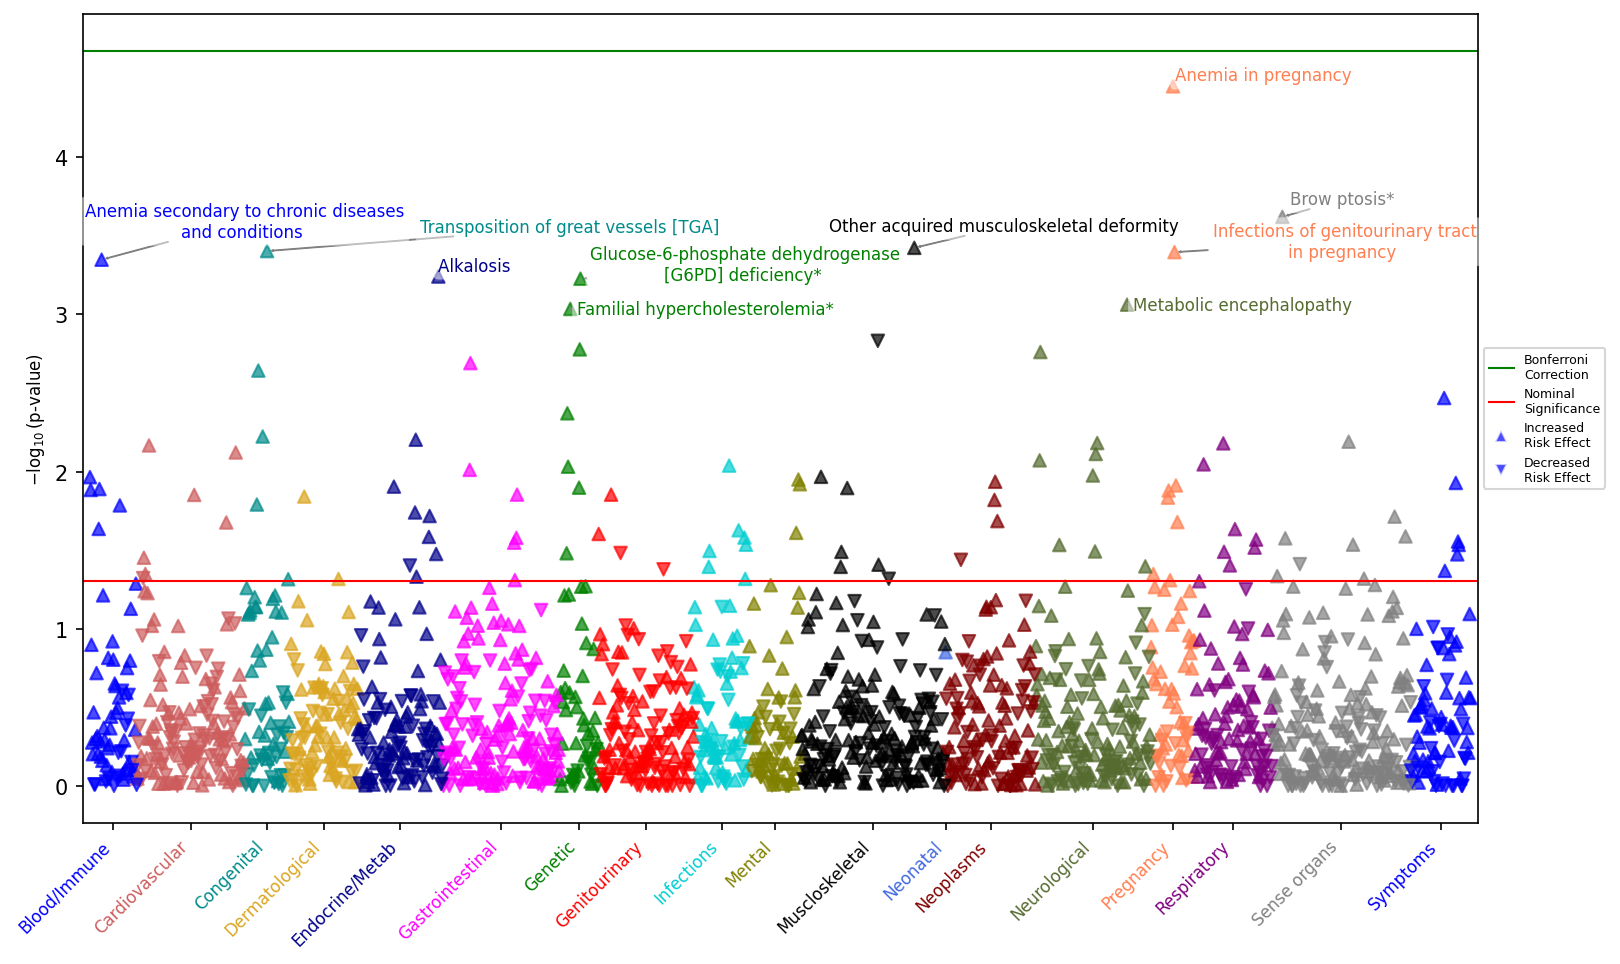

In [6]:
from phetk.plot import Plot

p = Plot("phewas_results.tsv", converged_only=True)

p.manhattan(
    label_values="p_value",
    label_count=10,
    save_plot=True,
    output_file_path="manhattan_plot.png"
)

In [7]:
import pandas as pd

results = pd.read_csv("phewas_results.tsv", sep="\t")

# sort by p-value
results_sorted = results.sort_values("p_value")

# show top 10
results_sorted.head(10)

,phecode,cases,controls,p_value,neg_log_p_value,standard_error,beta,conf_int_1,conf_int_2,odds_ratio,log10_odds_ratio,converged,phecode_sex_restriction,phecode_string,phecode_category
42,CA_114.12,50,225546,1.538140e-17,16.813004,0.426,3.634131,2.799,4.470,37.868928,1.578283,False,Both,Merkel cell carcinoma,Neoplasms
924,PP_914,1444,136753,3.532938e-05,4.451864,0.336,1.389819,0.731,2.048,4.014123,0.603591,True,Female,Anemia in pregnancy,Pregnancy
1685,SO_361.36,380,224843,2.392352e-04,3.621175,0.416,1.528450,0.713,2.344,4.611024,0.663797,True,Both,Brow ptosis*,Sense organs
997,MS_729,1205,222962,3.766269e-04,3.424089,0.307,1.091111,0.490,1.693,2.977580,0.473863,True,Both,Other acquired musculoskeletal deformity,Muscloskeletal
2136,CM_763.12,57,225527,3.948643e-04,3.403552,0.724,2.564067,1.146,3.982,12.988537,1.113560,True,Both,Transposition of great vessels [TGA],Congenital
384,PP_916.1,1115,136810,4.012743e-04,3.396559,0.374,1.325238,0.591,2.059,3.763081,0.575544,True,Female,Infections of genitourinary tract in pregnancy,Pregnancy
2314,BI_164.6,7664,213313,4.481754e-04,3.348552,0.171,0.599804,0.265,0.935,1.821761,0.260491,True,Both,Anemia secondary to chronic diseases and condi...,Blood/Immune
1203,EM_256.32,521,223813,5.736634e-04,3.241343,0.413,1.422110,0.613,2.231,4.145859,0.617615,True,Both,Alkalosis,Endocrine/Metab
276,GE_970.631,73,225492,5.923763e-04,3.227402,0.722,2.478517,1.064,3.893,11.923572,1.076406,True,Both,Glucose-6-phosphate dehydrogenase [G6PD] defic...,Genetic
1531,NS_345.2,1210,222834,8.664677e-04,3.062248,0.321,1.070385,0.441,1.700,2.916503,0.464862,True,Both,Metabolic encephalopathy,Neurological


In [8]:
results = pd.read_csv("phewas_results.tsv", sep="\t")

# look for LDLR-relevant phenotypes
results[results["phecode_string"].str.contains("cholesterol|lipid|athero|coronary", case=False, na=False)] \
    .sort_values("p_value") \
    .head(10)

,phecode,cases,controls,p_value,neg_log_p_value,standard_error,beta,conf_int_1,conf_int_2,odds_ratio,log10_odds_ratio,converged,phecode_sex_restriction,phecode_string,phecode_category
517,GE_965.4,475,224842,0.000923,3.034937,0.414,1.370058,0.560,2.181,3.935579,0.595009,True,Both,Familial hypercholesterolemia*,Genetic
559,EM_239.1,48220,165563,0.006273,2.202550,0.099,0.270143,0.076,0.464,1.310152,0.117322,True,Both,Hypercholesterolemia,Endocrine/Metab
2261,CV_404.23,1064,223499,0.006820,2.166222,0.341,0.923166,0.254,1.592,2.517248,0.400926,True,Both,Coronary atherosclerosis due to calcified coro...,Cardiovascular
1949,CV_418.2,1759,221271,0.014082,1.851321,0.295,0.723515,0.146,1.301,2.061667,0.314219,True,Both,Abnormal findings on diagnostic imaging of hea...,Cardiovascular
409,EM_239,88020,124353,0.018214,1.739599,0.096,0.226315,0.038,0.414,1.253971,0.098287,True,Both,Hyperlipidemia,Endocrine/Metab
472,EM_239.11,29052,186035,0.046675,1.330912,0.115,0.228386,0.003,0.453,1.256571,0.099187,True,Both,Pure hypercholesterolemia,Endocrine/Metab
960,CV_403.1,307,225060,0.057755,1.238409,0.582,1.105177,-0.036,2.247,3.019758,0.479972,True,Both,Coronary artery spasm [Coronary vasospasm]*,Cardiovascular
2158,CV_404.2,24005,194416,0.059399,1.226221,0.122,0.230484,-0.009,0.470,1.259210,0.100098,True,Both,Coronary atherosclerosis [Atherosclerotic hear...,Cardiovascular
1423,GE_963.1,155,225205,0.060632,1.217301,0.714,1.339673,-0.060,2.739,3.817793,0.581812,True,Both,Lipid storage disorders,Genetic
1225,EM_239.3,25645,192955,0.073153,1.135768,0.114,0.205163,-0.019,0.430,1.227725,0.089101,True,Both,Mixed hyperlipidemia,Endocrine/Metab


In [9]:
results_clean = results[results["converged"] == True]
results_clean.sort_values("p_value").head(10)

,phecode,cases,controls,p_value,neg_log_p_value,standard_error,beta,conf_int_1,conf_int_2,odds_ratio,log10_odds_ratio,converged,phecode_sex_restriction,phecode_string,phecode_category
924,PP_914,1444,136753,0.000035,4.451864,0.336,1.389819,0.731,2.048,4.014123,0.603591,True,Female,Anemia in pregnancy,Pregnancy
1685,SO_361.36,380,224843,0.000239,3.621175,0.416,1.528450,0.713,2.344,4.611024,0.663797,True,Both,Brow ptosis*,Sense organs
997,MS_729,1205,222962,0.000377,3.424089,0.307,1.091111,0.490,1.693,2.977580,0.473863,True,Both,Other acquired musculoskeletal deformity,Muscloskeletal
2136,CM_763.12,57,225527,0.000395,3.403552,0.724,2.564067,1.146,3.982,12.988537,1.113560,True,Both,Transposition of great vessels [TGA],Congenital
384,PP_916.1,1115,136810,0.000401,3.396559,0.374,1.325238,0.591,2.059,3.763081,0.575544,True,Female,Infections of genitourinary tract in pregnancy,Pregnancy
2314,BI_164.6,7664,213313,0.000448,3.348552,0.171,0.599804,0.265,0.935,1.821761,0.260491,True,Both,Anemia secondary to chronic diseases and condi...,Blood/Immune
1203,EM_256.32,521,223813,0.000574,3.241343,0.413,1.422110,0.613,2.231,4.145859,0.617615,True,Both,Alkalosis,Endocrine/Metab
276,GE_970.631,73,225492,0.000592,3.227402,0.722,2.478517,1.064,3.893,11.923572,1.076406,True,Both,Glucose-6-phosphate dehydrogenase [G6PD] defic...,Genetic
1531,NS_345.2,1210,222834,0.000866,3.062248,0.321,1.070385,0.441,1.700,2.916503,0.464862,True,Both,Metabolic encephalopathy,Neurological
517,GE_965.4,475,224842,0.000923,3.034937,0.414,1.370058,0.560,2.181,3.935579,0.595009,True,Both,Familial hypercholesterolemia*,Genetic
